# Modeling — SSH Anomaly Detection

Notebook này thực hiện toàn bộ quá trình **train model** và **evaluate** theo spec
trong `training_spec.md`.

**Pipeline:**
1. Load data + sanity check
2. Baseline (DummyClassifier)
3. Model training: Logistic Regression, Random Forest, LightGBM
4. Hyperparameter tuning (RandomizedSearchCV, 5-fold stratified)
5. Cross-validation evaluation (per-class metrics, confusion matrix)
6. Time-based holdout evaluation
7. Feature importance
8. Model comparison + selection
9. Export artifacts

In [1]:
import sys, os, warnings
sys.path.insert(0, '../src')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb

from sklearn.model_selection import (
    StratifiedKFold, RandomizedSearchCV, cross_val_predict,
)
from sklearn.metrics import (
    f1_score, classification_report, confusion_matrix,
)

from feature_engineering import CLASS_NAMES, TRAINING_FEATURES

sns.set_theme(style='whitegrid', palette='Set2', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

RANDOM_STATE = 42
DATA_DIR = Path('../data/processed')
MODEL_DIR = Path('../models')
MODEL_DIR.mkdir(exist_ok=True)

CLASS_LABELS = [CLASS_NAMES[i] for i in range(5)]

---
## 1. Load Data

In [2]:
# Full dataset (for CV)
X = pd.read_csv(DATA_DIR / 'X_train_ready.csv')
y = pd.read_csv(DATA_DIR / 'y_train_ready.csv').squeeze()

# Time-based holdout
X_time_train = pd.read_csv(DATA_DIR / 'X_time_train.csv')
y_time_train = pd.read_csv(DATA_DIR / 'y_time_train.csv').squeeze()
X_time_test  = pd.read_csv(DATA_DIR / 'X_time_test.csv')
y_time_test  = pd.read_csv(DATA_DIR / 'y_time_test.csv').squeeze()

print(f'CV dataset:       X={X.shape}, y={y.shape}')
print(f'Time train:       X={X_time_train.shape}')
print(f'Time test:        X={X_time_test.shape}')
print(f'\nFeatures ({X.shape[1]}): {list(X.columns)}')

print(f'\nClass distribution (full dataset):')
for cls in range(5):
    n = (y == cls).sum()
    print(f'  {cls} {CLASS_NAMES[cls]:17s}: {n:>5} ({n/len(y)*100:5.2f}%)')

CV dataset:       X=(3916, 11), y=(3916,)
Time train:       X=(3107, 11)
Time test:        X=(809, 11)

Features (11): ['is_private', 'session_duration', 'attempts_per_second', 'is_single_event', 'failure_ratio', 'unique_users_ratio', 'has_root_attempt', 'has_valid_user_attempt', 'max_failure_streak', 'invalid_user_attempts', 'has_reverse_mapping_failed']

Class distribution (full dataset):
  0 Normal           :   123 ( 3.14%)
  1 Single failure   :  2542 (64.91%)
  2 Scan             :   192 ( 4.90%)
  3 Brute-force      :  1040 (26.56%)
  4 Break-in         :    19 ( 0.49%)


In [3]:
# CV setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
print('CV: StratifiedKFold(n_splits=5, shuffle=True, random_state=42)')

CV: StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


---
## 2. Baseline

In [4]:
baseline = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
y_pred_baseline = cross_val_predict(baseline, X, y, cv=cv)

baseline_macro_f1 = f1_score(y, y_pred_baseline, average='macro')
baseline_weighted_f1 = f1_score(y, y_pred_baseline, average='weighted')

print(f'Baseline (most_frequent):')
print(f'  Always predicts: class {y.mode()[0]} ({CLASS_NAMES[y.mode()[0]]})')
print(f'  CV Macro F1:    {baseline_macro_f1:.4f}')
print(f'  CV Weighted F1: {baseline_weighted_f1:.4f}')
print(f'\n→ Any real model must beat macro F1 = {baseline_macro_f1:.4f}')

Baseline (most_frequent):
  Always predicts: class 1 (Single failure)
  CV Macro F1:    0.1574
  CV Weighted F1: 0.5110

→ Any real model must beat macro F1 = 0.1574


---
## 3. Model Training + Hyperparameter Tuning

3 model candidates được tune bằng `RandomizedSearchCV` (n_iter=20),
scoring = `f1_macro`, refit trên toàn bộ data sau khi tìm best params.

In [5]:
def tune_model(name, estimator, param_distributions, X, y, cv, n_iter=20):
    """Tune a model with RandomizedSearchCV and return results."""
    print(f'\n{"="*60}')
    print(f'Tuning: {name}')
    print(f'{"="*60}')

    if param_distributions:
        search = RandomizedSearchCV(
            estimator,
            param_distributions,
            n_iter=n_iter,
            scoring='f1_macro',
            cv=cv,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            refit=True,
        )
        search.fit(X, y)
        best_model = search.best_estimator_
        cv_score = search.best_score_
        best_params = search.best_params_
    else:
        # No tuning needed (e.g. Logistic Regression)
        from sklearn.model_selection import cross_val_score
        scores = cross_val_score(estimator, X, y, cv=cv, scoring='f1_macro')
        estimator.fit(X, y)
        best_model = estimator
        cv_score = scores.mean()
        best_params = {}
        print(f'  CV scores per fold: {scores.round(4)}')

    print(f'  Best CV Macro F1: {cv_score:.4f}')
    if best_params:
        print(f'  Best params: {best_params}')

    return best_model, cv_score, best_params

In [6]:
# --- Define models and param grids ---
models_config = [
    (
        'LogisticReg',
        LogisticRegression(
            class_weight='balanced',
            max_iter=1000,
            random_state=RANDOM_STATE,
        ),
        {},  # no tuning
    ),
    (
        'RandomForest',
        RandomForestClassifier(
            n_estimators=300,
            class_weight='balanced',
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        {
            'max_depth': [None, 10, 20],
            'min_samples_leaf': [1, 2, 5],
            'max_features': ['sqrt', 'log2'],
        },
    ),
    (
        'LightGBM',
        lgb.LGBMClassifier(
            n_estimators=500,
            class_weight='balanced',
            learning_rate=0.05,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=-1,
        ),
        {
            'max_depth': [4, 6, 8],
            'num_leaves': [15, 31, 63],
            'min_child_samples': [5, 10, 20],
            'subsample': [0.8, 1.0],
        },
    ),
]

# --- Train all models ---
results = {}
for name, estimator, params in models_config:
    best_model, cv_score, best_params = tune_model(
        name, estimator, params, X, y, cv
    )
    results[name] = {
        'model': best_model,
        'cv_macro_f1': cv_score,
        'params': best_params,
    }

print(f'\n{"="*60}')
print('Summary:')
print(f'{"="*60}')
for name, res in results.items():
    print(f'  {name:15s}: CV Macro F1 = {res["cv_macro_f1"]:.4f}')


Tuning: LogisticReg


  CV scores per fold: [0.9542 0.9571 0.9709 0.9488 0.9671]
  Best CV Macro F1: 0.9596

Tuning: RandomForest


  Best CV Macro F1: 0.9950
  Best params: {'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None}

Tuning: LightGBM


  Best CV Macro F1: 1.0000
  Best params: {'subsample': 1.0, 'num_leaves': 15, 'min_child_samples': 5, 'max_depth': 6}

Summary:
  LogisticReg    : CV Macro F1 = 0.9596
  RandomForest   : CV Macro F1 = 0.9950
  LightGBM       : CV Macro F1 = 1.0000


---
## 4. Cross-Validation Evaluation

Dùng `cross_val_predict` để lấy out-of-fold predictions cho **toàn bộ dataset**,
rồi tính per-class metrics. Đây là đánh giá chính cho tất cả 5 class (bao gồm Break-in).

In [7]:
# Get CV predictions for each model
cv_predictions = {}
cv_reports = {}

for name, res in results.items():
    model = res['model']
    y_pred_cv = cross_val_predict(model, X, y, cv=cv)
    cv_predictions[name] = y_pred_cv

    macro_f1 = f1_score(y, y_pred_cv, average='macro')
    weighted_f1 = f1_score(y, y_pred_cv, average='weighted')
    per_class_f1 = f1_score(y, y_pred_cv, average=None)

    report_str = classification_report(
        y, y_pred_cv, target_names=CLASS_LABELS, digits=4
    )
    cv_reports[name] = report_str

    print(f'\n{"="*60}')
    print(f'{name} — CV Classification Report')
    print(f'{"="*60}')
    print(report_str)
    print(f'Macro F1: {macro_f1:.4f}  |  Weighted F1: {weighted_f1:.4f}')


LogisticReg — CV Classification Report
                precision    recall  f1-score   support

        Normal     1.0000    1.0000    1.0000       123
Single failure     0.9996    0.9811    0.9903      2542
          Scan     0.7143    0.9896    0.8297       192
   Brute-force     0.9901    0.9644    0.9771      1040
      Break-in     1.0000    1.0000    1.0000        19

      accuracy                         0.9778      3916
     macro avg     0.9408    0.9870    0.9594      3916
  weighted avg     0.9831    0.9778    0.9793      3916

Macro F1: 0.9594  |  Weighted F1: 0.9793



RandomForest — CV Classification Report
                precision    recall  f1-score   support

        Normal     1.0000    1.0000    1.0000       123
Single failure     1.0000    1.0000    1.0000      2542
          Scan     1.0000    0.9948    0.9974       192
   Brute-force     1.0000    1.0000    1.0000      1040
      Break-in     0.9500    1.0000    0.9744        19

      accuracy                         0.9997      3916
     macro avg     0.9900    0.9990    0.9943      3916
  weighted avg     0.9998    0.9997    0.9997      3916

Macro F1: 0.9943  |  Weighted F1: 0.9997



LightGBM — CV Classification Report
                precision    recall  f1-score   support

        Normal     1.0000    1.0000    1.0000       123
Single failure     1.0000    1.0000    1.0000      2542
          Scan     1.0000    1.0000    1.0000       192
   Brute-force     1.0000    1.0000    1.0000      1040
      Break-in     1.0000    1.0000    1.0000        19

      accuracy                         1.0000      3916
     macro avg     1.0000    1.0000    1.0000      3916
  weighted avg     1.0000    1.0000    1.0000      3916

Macro F1: 1.0000  |  Weighted F1: 1.0000


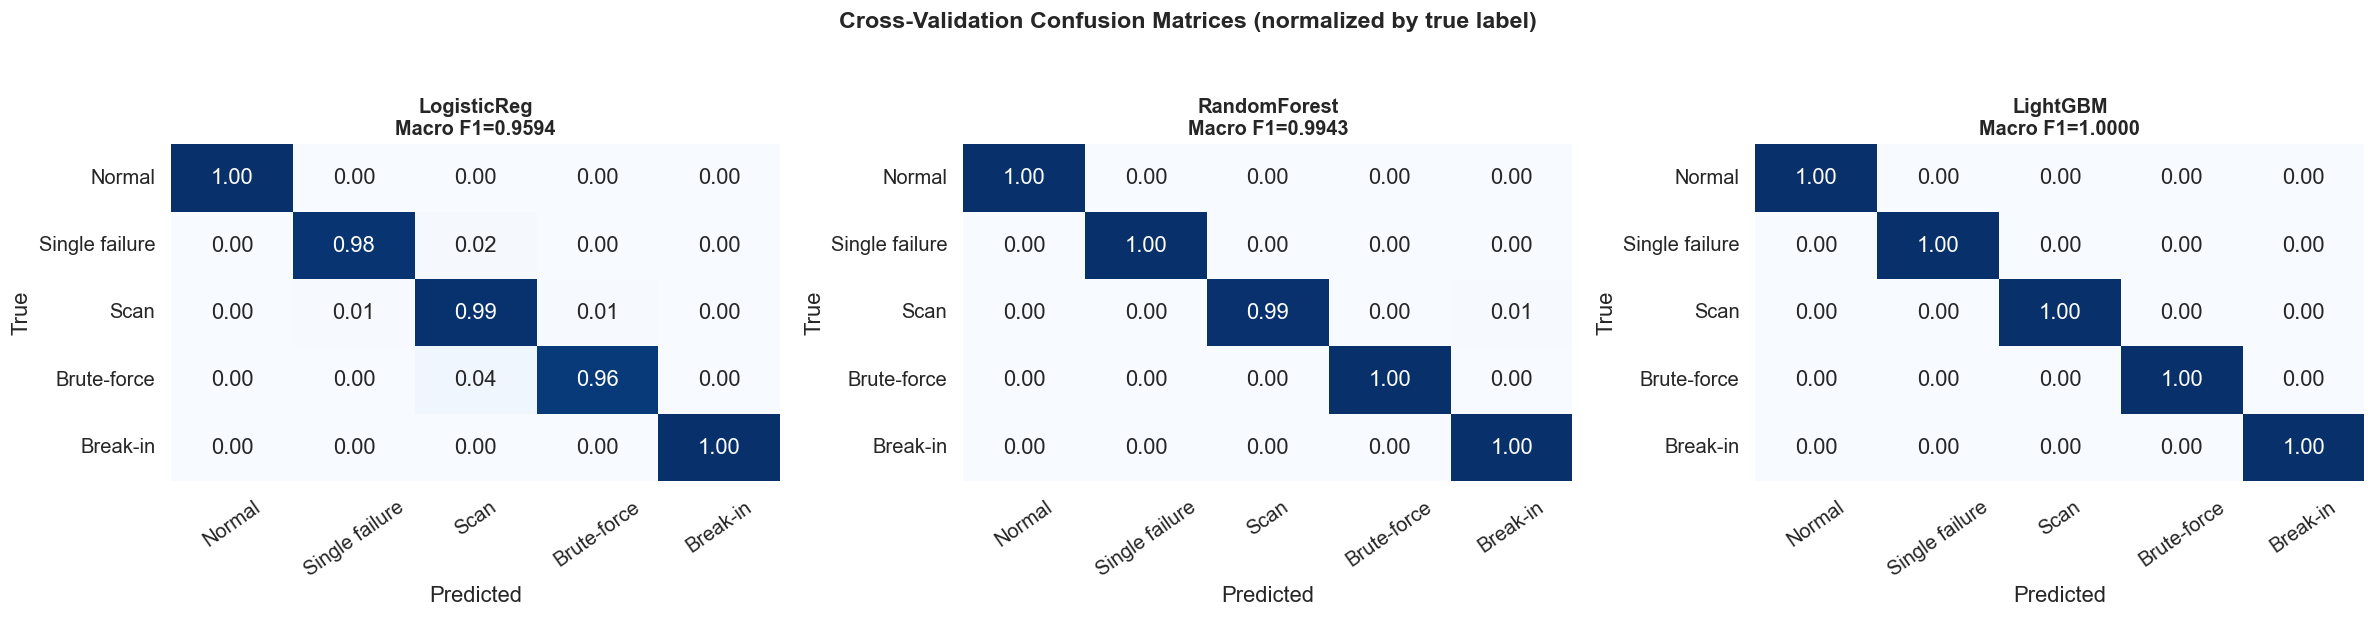

Saved: ..\models\cv_confusion_matrices.png


In [8]:
# CV Confusion matrices — side by side
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for ax, (name, y_pred_cv) in zip(axes, cv_predictions.items()):
    cm = confusion_matrix(y, y_pred_cv, normalize='true')
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=CLASS_LABELS, yticklabels=CLASS_LABELS,
                ax=ax, vmin=0, vmax=1, cbar=False)
    macro_f1 = f1_score(y, y_pred_cv, average='macro')
    ax.set_title(f'{name}\nMacro F1={macro_f1:.4f}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.tick_params(axis='x', rotation=35)
    ax.tick_params(axis='y', rotation=0)

plt.suptitle('Cross-Validation Confusion Matrices (normalized by true label)',
             fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig(MODEL_DIR / 'cv_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {MODEL_DIR / "cv_confusion_matrices.png"}')

---
## 5. Model Comparison

In [9]:
# Build comparison table
comparison_rows = []
for name, y_pred_cv in cv_predictions.items():
    per_class_f1 = f1_score(y, y_pred_cv, average=None)
    macro_f1 = f1_score(y, y_pred_cv, average='macro')
    weighted_f1 = f1_score(y, y_pred_cv, average='weighted')

    row = {
        'Model': name,
        'CV Macro F1': macro_f1,
        'CV Weighted F1': weighted_f1,
    }
    for cls in range(5):
        row[f'F1 {CLASS_NAMES[cls]}'] = per_class_f1[cls]
    comparison_rows.append(row)

# Add baseline
per_class_baseline = f1_score(y, y_pred_baseline, average=None)
baseline_row = {
    'Model': 'Baseline',
    'CV Macro F1': baseline_macro_f1,
    'CV Weighted F1': baseline_weighted_f1,
}
for cls in range(5):
    baseline_row[f'F1 {CLASS_NAMES[cls]}'] = per_class_baseline[cls]
comparison_rows.insert(0, baseline_row)

comparison_df = pd.DataFrame(comparison_rows)
comparison_df = comparison_df.sort_values('CV Macro F1', ascending=False)
comparison_df

,Model,CV Macro F1,CV Weighted F1,F1 Normal,F1 Single failure,F1 Scan,F1 Brute-force,F1 Break-in
3,LightGBM,1.000000,1.000000,1.0,1.000000,1.000000,1.000000,1.000000
2,RandomForest,0.994350,0.999748,1.0,1.000000,0.997389,1.000000,0.974359
1,LogisticReg,0.959415,0.979255,1.0,0.990272,0.829694,0.977107,1.000000
0,Baseline,0.157448,0.511023,0.0,0.787241,0.000000,0.000000,0.000000


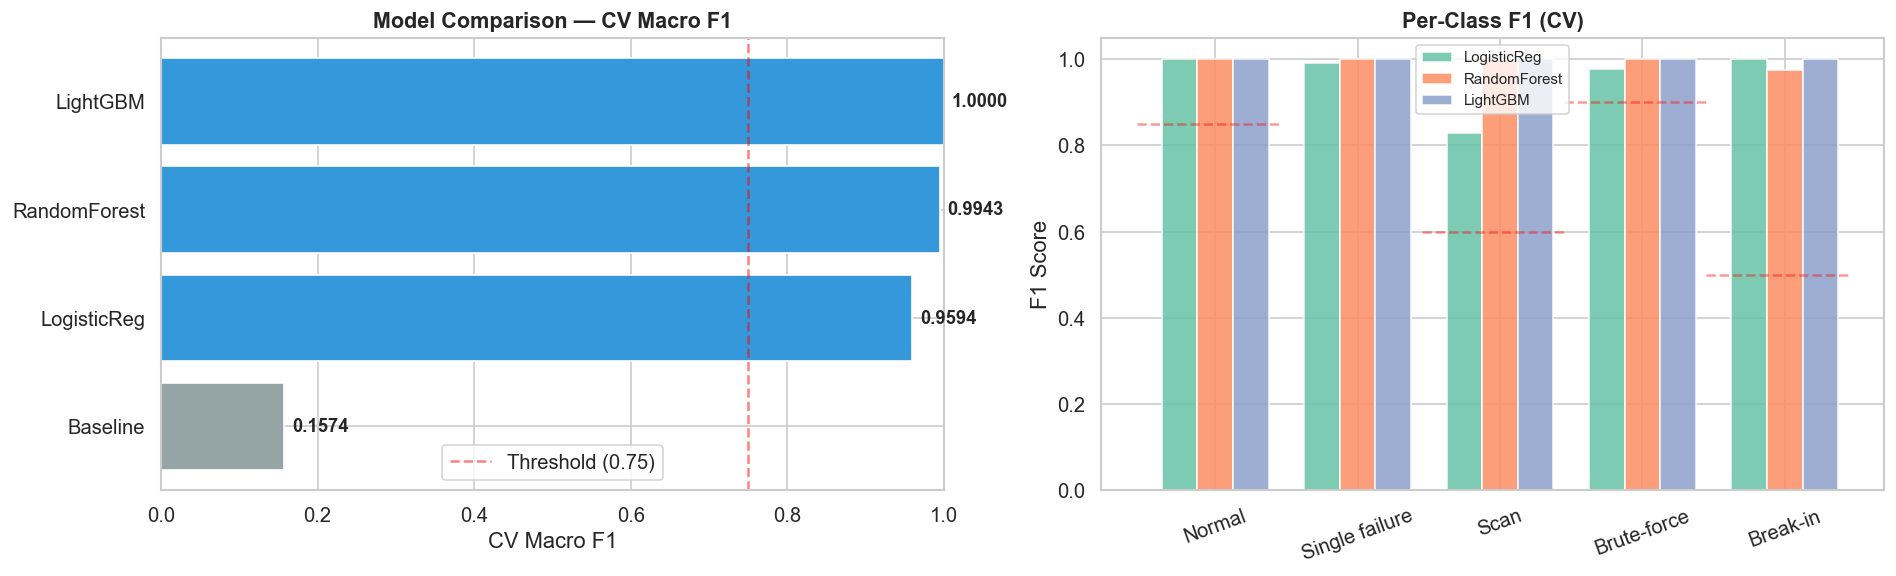

Saved: ..\models\model_comparison.png


In [10]:
# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Macro F1 bar chart
ax = axes[0]
models_sorted = comparison_df.sort_values('CV Macro F1')
colors = ['#95a5a6' if m == 'Baseline' else '#3498db' for m in models_sorted['Model']]
bars = ax.barh(models_sorted['Model'], models_sorted['CV Macro F1'],
               color=colors, edgecolor='white')
for bar, val in zip(bars, models_sorted['CV Macro F1']):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=11, fontweight='bold')
ax.set_xlim(0, 1.0)
ax.set_xlabel('CV Macro F1')
ax.set_title('Model Comparison — CV Macro F1', fontsize=13, fontweight='bold')
ax.axvline(0.75, color='red', linestyle='--', alpha=0.5, label='Threshold (0.75)')
ax.legend()

# Per-class F1 grouped bar chart
ax = axes[1]
model_names = [r['Model'] for r in comparison_rows if r['Model'] != 'Baseline']
x = np.arange(5)
width = 0.25
for i, name in enumerate(model_names):
    row = comparison_df[comparison_df['Model'] == name].iloc[0]
    f1s = [row[f'F1 {CLASS_NAMES[cls]}'] for cls in range(5)]
    ax.bar(x + i * width, f1s, width, label=name, alpha=0.85)

ax.set_xticks(x + width)
ax.set_xticklabels(CLASS_LABELS, rotation=20)
ax.set_ylabel('F1 Score')
ax.set_ylim(0, 1.05)
ax.set_title('Per-Class F1 (CV)', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)

# Threshold lines
thresholds = {0: 0.85, 2: 0.60, 3: 0.90, 4: 0.50}
for cls, thresh in thresholds.items():
    ax.hlines(thresh, cls - 0.3, cls + 0.7, colors='red',
              linestyles='--', alpha=0.4)

plt.tight_layout()
plt.savefig(MODEL_DIR / 'model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {MODEL_DIR / "model_comparison.png"}')

In [11]:
# Threshold check
thresholds = {
    'CV Macro F1': 0.75,
    'F1 Normal': 0.85,
    'F1 Brute-force': 0.90,
    'F1 Scan': 0.60,
    'F1 Break-in': 0.50,
}

print('=== Threshold Check (from training_spec.md) ===\n')
for name in model_names:
    row = comparison_df[comparison_df['Model'] == name].iloc[0]
    print(f'{name}:')
    all_pass = True
    for metric, thresh in thresholds.items():
        val = row[metric]
        passed = val >= thresh
        status = 'PASS' if passed else 'FAIL'
        icon = '  ' if passed else ''
        print(f'  {metric:22s}: {val:.4f} >= {thresh:.2f}  {status}')
        if not passed:
            all_pass = False
    print(f'  {"ALL PASSED" if all_pass else "SOME FAILED"}\n')

=== Threshold Check (from training_spec.md) ===

LogisticReg:
  CV Macro F1           : 0.9594 >= 0.75  PASS
  F1 Normal             : 1.0000 >= 0.85  PASS
  F1 Brute-force        : 0.9771 >= 0.90  PASS
  F1 Scan               : 0.8297 >= 0.60  PASS
  F1 Break-in           : 1.0000 >= 0.50  PASS
  ALL PASSED

RandomForest:
  CV Macro F1           : 0.9943 >= 0.75  PASS
  F1 Normal             : 1.0000 >= 0.85  PASS
  F1 Brute-force        : 1.0000 >= 0.90  PASS
  F1 Scan               : 0.9974 >= 0.60  PASS
  F1 Break-in           : 0.9744 >= 0.50  PASS
  ALL PASSED

LightGBM:
  CV Macro F1           : 1.0000 >= 0.75  PASS
  F1 Normal             : 1.0000 >= 0.85  PASS
  F1 Brute-force        : 1.0000 >= 0.90  PASS
  F1 Scan               : 1.0000 >= 0.60  PASS
  F1 Break-in           : 1.0000 >= 0.50  PASS
  ALL PASSED



In [12]:
# Select best model
best_name = comparison_df[comparison_df['Model'] != 'Baseline'].iloc[0]['Model']
best_row = comparison_df[comparison_df['Model'] == best_name].iloc[0]

# Check tie-breaking rule: if diff <= 0.01, prefer simpler model
top_models = comparison_df[comparison_df['Model'] != 'Baseline'].head(2)
if len(top_models) >= 2:
    diff = top_models.iloc[0]['CV Macro F1'] - top_models.iloc[1]['CV Macro F1']
    if diff <= 0.01:
        # Prefer RF over LightGBM (simpler)
        simplicity_order = ['LogisticReg', 'RandomForest', 'LightGBM']
        candidates = top_models['Model'].tolist()
        for s in simplicity_order:
            if s in candidates:
                best_name = s
                best_row = comparison_df[comparison_df['Model'] == best_name].iloc[0]
                break
        print(f'Top 2 models within 0.01 — choosing simpler: {best_name}')
    else:
        print(f'Clear winner (diff={diff:.4f} > 0.01): {best_name}')

best_model = results[best_name]['model']
print(f'\n*** Selected: {best_name} ***')
print(f'CV Macro F1: {best_row["CV Macro F1"]:.4f}')
print(f'Params: {results[best_name]["params"]}')

Top 2 models within 0.01 — choosing simpler: RandomForest

*** Selected: RandomForest ***
CV Macro F1: 0.9943
Params: {'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None}


---
## 6. Time-based Holdout Evaluation

Train best model trên `time_train` (ngày 1–21), test trên `time_test` (ngày 22–28).

⚠️ **Break-in (class 4)**: chỉ ~7 samples trong test set — metrics không đáng tin cậy cho class này.

In [13]:
# Train on time_train, predict on time_test
best_model.fit(X_time_train, y_time_train)
y_pred_holdout = best_model.predict(X_time_test)

holdout_macro_f1 = f1_score(y_time_test, y_pred_holdout, average='macro')
holdout_report = classification_report(
    y_time_test, y_pred_holdout, target_names=CLASS_LABELS, digits=4,
    zero_division=0
)

print(f'{best_name} — Time Holdout Classification Report')
print(f'={""*58}')
print(holdout_report)
print(f'Holdout Macro F1: {holdout_macro_f1:.4f}')

# Small class warning
MIN_TEST_SAMPLES = 10
print(f'\nClass size warnings:')
for cls in range(5):
    count = (y_time_test == cls).sum()
    if count < MIN_TEST_SAMPLES:
        print(f'  class {cls} ({CLASS_NAMES[cls]}): only {count} samples — metrics unreliable')

RandomForest — Time Holdout Classification Report
=
                precision    recall  f1-score   support

        Normal     1.0000    1.0000    1.0000        58
Single failure     1.0000    1.0000    1.0000       344
          Scan     1.0000    0.9787    0.9892        47
   Brute-force     1.0000    1.0000    1.0000       353
      Break-in     0.8750    1.0000    0.9333         7

      accuracy                         0.9988       809
     macro avg     0.9750    0.9957    0.9845       809
  weighted avg     0.9989    0.9988    0.9988       809

Holdout Macro F1: 0.9845

Class size warnings:
  class 4 (Break-in): only 7 samples — metrics unreliable


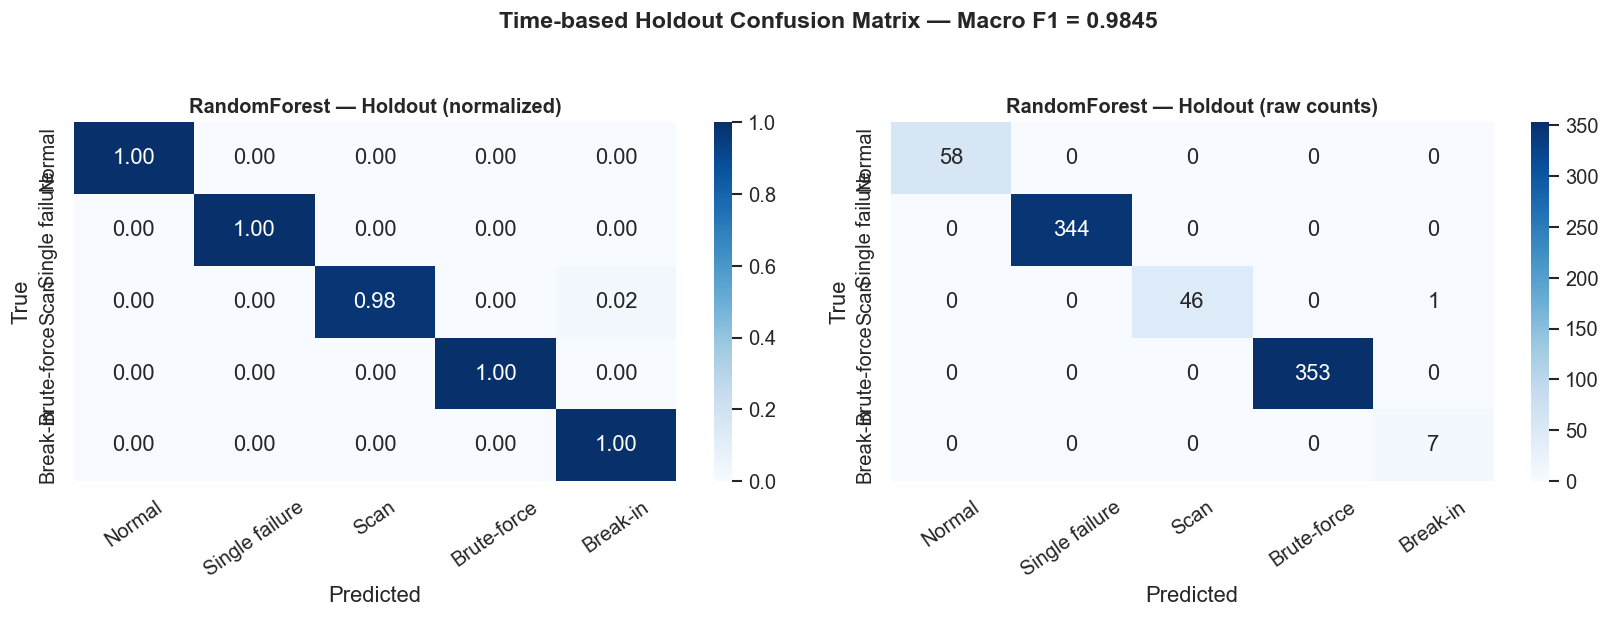

Saved: ..\models\confusion_matrix.png


In [14]:
# Holdout confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Normalized
cm_norm = confusion_matrix(y_time_test, y_pred_holdout, normalize='true')
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CLASS_LABELS, yticklabels=CLASS_LABELS,
            ax=axes[0], vmin=0, vmax=1)
axes[0].set_title(f'{best_name} — Holdout (normalized)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].tick_params(axis='x', rotation=35)

# Raw counts
cm_raw = confusion_matrix(y_time_test, y_pred_holdout)
sns.heatmap(cm_raw, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_LABELS, yticklabels=CLASS_LABELS,
            ax=axes[1])
axes[1].set_title(f'{best_name} — Holdout (raw counts)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')
axes[1].tick_params(axis='x', rotation=35)

plt.suptitle(f'Time-based Holdout Confusion Matrix — Macro F1 = {holdout_macro_f1:.4f}',
             fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig(MODEL_DIR / 'confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {MODEL_DIR / "confusion_matrix.png"}')

---
## 7. Feature Importance

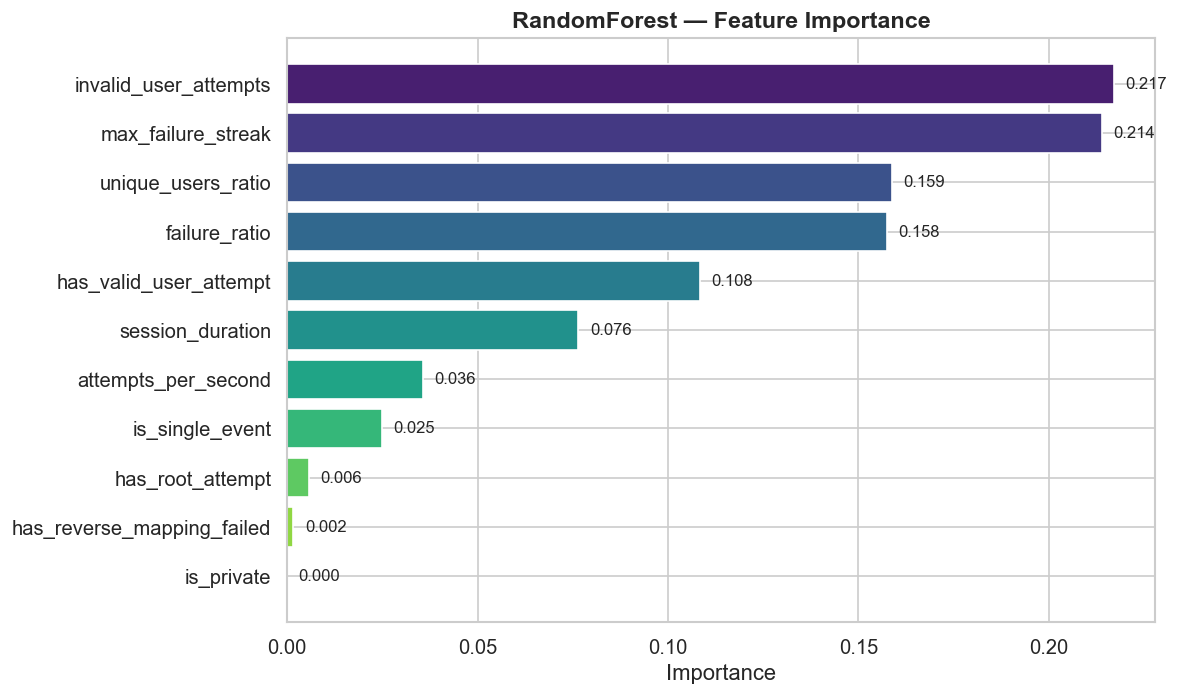

Saved: ..\models\feature_importance.png

Feature importance ranking:
   1. invalid_user_attempts         : 0.2170
   2. max_failure_streak            : 0.2139
   3. unique_users_ratio            : 0.1589
   4. failure_ratio                 : 0.1576
   5. has_valid_user_attempt        : 0.1083
   6. session_duration              : 0.0765
   7. attempts_per_second           : 0.0357
   8. is_single_event               : 0.0248
   9. has_root_attempt              : 0.0058
  10. has_reverse_mapping_failed    : 0.0016
  11. is_private                    : 0.0000


In [15]:
# Feature importance (tree-based models)
if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(
        best_model.feature_importances_,
        index=X.columns
    ).sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(10, 6))
    colors = sns.color_palette('viridis', len(importances))
    bars = ax.barh(importances.index[::-1], importances.values[::-1],
                   color=colors[::-1], edgecolor='white')
    for bar, val in zip(bars, importances.values[::-1]):
        ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=10)
    ax.set_xlabel('Importance')
    ax.set_title(f'{best_name} — Feature Importance', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(MODEL_DIR / 'feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {MODEL_DIR / "feature_importance.png"}')

    print(f'\nFeature importance ranking:')
    for i, (feat, imp) in enumerate(importances.items(), 1):
        print(f'  {i:2d}. {feat:30s}: {imp:.4f}')
else:
    # Logistic Regression — use coefficients
    print('Model does not have feature_importances_.')
    if hasattr(best_model, 'coef_'):
        print('Logistic Regression coefficients (per class):')
        coef_df = pd.DataFrame(
            best_model.coef_,
            columns=X.columns,
            index=[CLASS_NAMES[i] for i in range(5)]
        ).T
        print(coef_df.round(3))
    importances = None

---
## 8. Export Artifacts

In [16]:
# 1. Model comparison CSV
comparison_path = MODEL_DIR / 'model_comparison.csv'
comparison_df.to_csv(comparison_path, index=False)
print(f'[1] Model comparison:    {comparison_path}')

# 2. Best model pickle
# Refit best model on FULL dataset for deployment
best_model.fit(X, y)
model_path = MODEL_DIR / 'best_model.pkl'
joblib.dump(best_model, model_path)
print(f'[2] Best model ({best_name}): {model_path}')

# 3. CV classification report
cv_report_path = MODEL_DIR / 'cv_classification_report.txt'
with open(cv_report_path, 'w') as f:
    f.write(f'Model: {best_name}\n')
    f.write(f'Best params: {results[best_name]["params"]}\n\n')
    f.write(cv_reports[best_name])
print(f'[3] CV report:           {cv_report_path}')

# 4. Holdout classification report
holdout_report_path = MODEL_DIR / 'holdout_classification_report.txt'
with open(holdout_report_path, 'w') as f:
    f.write(f'Model: {best_name}\n')
    f.write(f'Holdout Macro F1: {holdout_macro_f1:.4f}\n\n')
    f.write(holdout_report)
print(f'[4] Holdout report:      {holdout_report_path}')

# 5. Feature importance CSV
if importances is not None:
    fi_path = MODEL_DIR / 'feature_importance.csv'
    importances.to_csv(fi_path, header=['importance'])
    print(f'[5] Feature importance:  {fi_path}')

print(f'\nAll artifacts saved to: {MODEL_DIR.resolve()}')

[1] Model comparison:    ..\models\model_comparison.csv


[2] Best model (RandomForest): ..\models\best_model.pkl
[3] CV report:           ..\models\cv_classification_report.txt
[4] Holdout report:      ..\models\holdout_classification_report.txt
[5] Feature importance:  ..\models\feature_importance.csv

All artifacts saved to: D:\SSH-anomaly-detection-using-ML\models


In [17]:
# Final summary
print('=' * 60)
print('TRAINING COMPLETE')
print('=' * 60)
print(f'\nSelected model: {best_name}')
print(f'Best params:    {results[best_name]["params"]}')
print(f'\nCV Macro F1:      {best_row["CV Macro F1"]:.4f}')
print(f'Holdout Macro F1: {holdout_macro_f1:.4f}')

print(f'\nPer-class F1 (CV):')
per_class = f1_score(y, cv_predictions[best_name], average=None)
for cls in range(5):
    thresh = thresholds.get(f'F1 {CLASS_NAMES[cls]}', None)
    status = ''
    if thresh:
        status = f'  (threshold: {thresh:.2f} {"PASS" if per_class[cls] >= thresh else "FAIL"})'
    print(f'  {cls} {CLASS_NAMES[cls]:17s}: {per_class[cls]:.4f}{status}')

print(f'\nArtifacts in: {MODEL_DIR.resolve()}')
for f in sorted(MODEL_DIR.iterdir()):
    if f.is_file():
        size_kb = f.stat().st_size / 1024
        print(f'  {f.name:40s} {size_kb:>8.1f} KB')

TRAINING COMPLETE

Selected model: RandomForest
Best params:    {'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None}

CV Macro F1:      0.9943
Holdout Macro F1: 0.9845

Per-class F1 (CV):
  0 Normal           : 1.0000  (threshold: 0.85 PASS)
  1 Single failure   : 1.0000
  2 Scan             : 0.9974  (threshold: 0.60 PASS)
  3 Brute-force      : 1.0000  (threshold: 0.90 PASS)
  4 Break-in         : 0.9744  (threshold: 0.50 PASS)

Artifacts in: D:\SSH-anomaly-detection-using-ML\models
  .gitkeep                                      0.0 KB
  best_model.pkl                             1127.5 KB
  confusion_matrix.png                        103.4 KB
  cv_classification_report.txt                  0.6 KB
  cv_confusion_matrices.png                   105.6 KB
  feature_importance.csv                        0.4 KB
  feature_importance.png                       71.9 KB
  holdout_classification_report.txt             0.6 KB
  model_comparison.csv                          0.4 KB
 